# Introduction to scalable computing with Dask

---

## What is Dask?

<img src="images/dask-logo.svg" width="20%" align="right"/>

A library for **parallel and distributed computing in Python**.

Traditionally PyData libraries were designed for linear workflows (for example NumPy, pandas, scikit-learn),
Dask provides a similar API to run the same computations in parallel.

## Parallel computing

Computing parts of a workflow simultaneously. Typically, we use this term to describe single-machine parallelism, where your computation can be run simultaneously on various cores of a machine while sharing the same memory (RAM).

## Dask DataFrame API

Dask has a few different APIs to parallelize different tools/activities. We will primarily cover Dask's DataFrame API, which parallelizes pandas, in this tutorial.

The idea is to provide a familiar interface to pandas, but leverage parallelism under-the-hood.

In [8]:
import dask.dataframe as dd

In [9]:
import os
os.listdir()

['.config',
 'On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2022_1.csv',
 'sample_data']

In [10]:
import dask.dataframe as dd
import requests
import zipfile
import io
import os

# Link dữ liệu tháng 1/2022
url = (
    "https://transtats.bts.gov/PREZIP/"
    "On_Time_Reporting_Carrier_On_Time_Performance_"
    "1987_present_2022_1.zip"
)

# Tải file ZIP
r = requests.get(url)
r.raise_for_status()

# Giải nén file CSV vào /content
with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    csv_file = [
        f for f in z.namelist()
        if f.endswith(".csv")
    ][0]

    z.extract(csv_file, "/content")

# Đường dẫn file CSV sau khi giải nén
csv_path = os.path.join("/content", csv_file)

print("Đã tải file:")
print(csv_path)

# Khai báo kiểu dữ liệu cho các cột Dask đang đọc sai
dtype_dict = {
    "CancellationCode": "object",
    "Div1Airport": "object",
    "Div1TailNum": "object",
    "Div2Airport": "object",
    "Div2TailNum": "object"
}

# Đọc dữ liệu bằng Dask
ddf = dd.read_csv(
    csv_path,
    dtype=dtype_dict,
    assume_missing=True
)

# Hiển thị 5 dòng đầu
ddf.head()

Đã tải file:
/content/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2022_1.csv


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Unnamed: 109
0,2022.0,1.0,1.0,14.0,5.0,2022-01-14,YX,20452.0,YX,N119HQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022.0,1.0,1.0,15.0,6.0,2022-01-15,YX,20452.0,YX,N122HQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022.0,1.0,1.0,16.0,7.0,2022-01-16,YX,20452.0,YX,N412YX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022.0,1.0,1.0,17.0,1.0,2022-01-17,YX,20452.0,YX,N405YX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022.0,1.0,1.0,18.0,2.0,2022-01-18,YX,20452.0,YX,N420YX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
dtype_dict = {
    'ArrTime': 'float64',
    'ArrivalDelayGroups': 'float64',
    'CancellationCode': 'object',
    'DepTime': 'float64',
    'DepartureDelayGroups': 'float64',
    'Div1Airport': 'object',
    'Div1TailNum': 'object',
    'Div2Airport': 'object',
    'Div2TailNum': 'object',
    'WheelsOff': 'float64',
    'WheelsOn': 'float64'
}

ddf = dd.read_csv('On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2022_1.csv', dtype=dtype_dict)
ddf.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Unnamed: 109
0,2022,1,1,14,5,2022-01-14,YX,20452,YX,N119HQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022,1,1,15,6,2022-01-15,YX,20452,YX,N122HQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022,1,1,16,7,2022-01-16,YX,20452,YX,N412YX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022,1,1,17,1,2022-01-17,YX,20452,YX,N405YX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022,1,1,18,2,2022-01-18,YX,20452,YX,N420YX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
ddf.tail()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Unnamed: 109
179036,2022,1,1,6,4,2022-01-06,DL,19790,DL,N101DQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
179037,2022,1,1,6,4,2022-01-06,DL,19790,DL,N883DN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
179038,2022,1,1,6,4,2022-01-06,DL,19790,DL,N831DN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
179039,2022,1,1,6,4,2022-01-06,DL,19790,DL,N989AT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
179040,2022,1,1,6,4,2022-01-06,DL,19790,DL,N815DN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
ddf

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,Origin,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,Dest,DestCityName,DestState,DestStateFips,DestStateName,DestWac,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrTime,ArrDelay,ArrDelayMinutes,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,Cancelled,CancellationCode,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Flights,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,FirstDepTime,TotalAddGTime,LongestAddGTime,DivAirportLandings,DivReachedDest,DivActualElapsedTime,DivArrDelay,DivDistance,Div1Airport,Div1AirportID,Div1AirportSeqID,Div1WheelsOn,Div1TotalGTime,Div1LongestGTime,Div1WheelsOff,Div1TailNum,Div2Airport,Div2AirportID,Div2AirportSeqID,Div2WheelsOn,Div2TotalGTime,Div2LongestGTime,Div2WheelsOff,Div2TailNum,Div3Airport,Div3AirportID,Div3AirportSeqID,Div3WheelsOn,Div3TotalGTime,Div3LongestGTime,Div3WheelsOff,Div3TailNum,Div4Airport,Div4AirportID,Div4AirportSeqID,Div4WheelsOn,Div4TotalGTime,Div4LongestGTime,Div4WheelsOff,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Unnamed: 109
npartitions=3,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,int64,int64,int64,int64,int64,string,string,int64,string,string,int64,int64,int64,int64,string,string,string,int64,string,int64,int64,int64,int64,string,string,string,int64,string,int64,int64,float64,float64,float64,float64,float64,string,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,string,float64,string,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,string,float64,float64,float64,float64,float64,float64,string,string,float64,float64,float64,float64,float64,float64,string,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


### Lazy evaluation

Dask evaluates your computations lazily, this is what allows Dask to "scale" your computations. This means, Dask only creates the "logic" of your computation eagerly, i.e., what are the independent tasks that can be executed in parallel, what does that dependency tree (called "task graph" in Dask) look like.

In the previous cell, Dask has loaded only the metadata information for the DataFrame, but none of the actual values.

You can use `.compute()` to run/execute the computations:

In [14]:
ddf.Reporting_Airline.unique().compute()

,Reporting_Airline
0,DL
1,G4
2,QX
3,AS
4,B6
0,YX
1,UA
2,YV
3,F9
4,NK


In [15]:
print(ddf.columns)

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
       'Reporting_Airline', 'DOT_ID_Reporting_Airline',
       'IATA_CODE_Reporting_Airline', 'Tail_Number',
       ...
       'Div4TailNum', 'Div5Airport', 'Div5AirportID', 'Div5AirportSeqID',
       'Div5WheelsOn', 'Div5TotalGTime', 'Div5LongestGTime', 'Div5WheelsOff',
       'Div5TailNum', 'Unnamed: 109'],
      dtype='object', length=110)


Some commands like `.head()` also trigger an internal compute, so you get the

In [16]:
ddf.head() # ValueError: Mismatched dtypes found in `pd.read_csv`/`pd.read_table`.

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Unnamed: 109
0,2022,1,1,14,5,2022-01-14,YX,20452,YX,N119HQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022,1,1,15,6,2022-01-15,YX,20452,YX,N122HQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022,1,1,16,7,2022-01-16,YX,20452,YX,N412YX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022,1,1,17,1,2022-01-17,YX,20452,YX,N405YX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022,1,1,18,2,2022-01-18,YX,20452,YX,N420YX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Specify `dtypes`

The lazy behavior of Dask means it infers the datatypes using minimal information -- for CSV files, Dask uses the first row.

This behavior is different from pandas, which loads the entire dataset and then infers datatypes.

Hence, in Dask and distributed computing in general tt's a good practice to provide explicit dtypes, especially if you use CSV files. You can do this by exporting the dtypes of a subset of data, We've already prepared the dtypes for this tutorial:

In [17]:
# Khai báo kiểu dữ liệu trực tiếp thay cho file dtypes.json

dtypes = {
    "CancellationCode": "object",
    "Div1Airport": "object",
    "Div1TailNum": "object",
    "Div2Airport": "object",
    "Div2TailNum": "object"
}

print("Đã tạo dtypes thành công:")
print(dtypes)

Đã tạo dtypes thành công:
{'CancellationCode': 'object', 'Div1Airport': 'object', 'Div1TailNum': 'object', 'Div2Airport': 'object', 'Div2TailNum': 'object'}


(Optional: You can take a look at `prep/dtypes.json`)

In [18]:
ddf = dd.read_csv('On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2022_1.csv', dtype=dtypes)

In [19]:
import dask.dataframe as dd

csv_path = "/content/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2022_1.csv"

dtype_dict = {
    # Các cột chứa chữ
    "CancellationCode": "object",
    "Div1Airport": "object",
    "Div1TailNum": "object",
    "Div2Airport": "object",
    "Div2TailNum": "object",

    # Các cột có giá trị thiếu nên phải dùng float
    "ArrTime": "float64",
    "ArrivalDelayGroups": "float64",
    "DepTime": "float64",
    "DepartureDelayGroups": "float64",
    "WheelsOff": "float64",
    "WheelsOn": "float64"
}

ddf = dd.read_csv(
    csv_path,
    dtype=dtype_dict,
    assume_missing=True
)

print("Đọc dữ liệu thành công")

Đọc dữ liệu thành công


In [20]:
dtype_dict = {
    'ArrTime': 'float64',
    'ArrivalDelayGroups': 'float64',
    'CancellationCode': 'object',
    'DepTime': 'float64',
    'DepartureDelayGroups': 'float64',
    'Div1Airport': 'object',
    'Div1TailNum': 'object',
    'Div2Airport': 'object',
    'Div2TailNum': 'object',
    'WheelsOff': 'float64',
    'WheelsOn': 'float64'
}

ddf = dd.read_csv('On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2022_1.csv', dtype=dtype_dict)

When we do computations, Dask keeps track of the parallel logic based on what it expects the output structure for each operation to look like.

In [21]:
add = ddf.Distance.sum()
add

<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(7a76fff))['Distance'].sum(), dtype=float64>

In the following task graph, everything in the same horizontal layer will be executed in parallel.

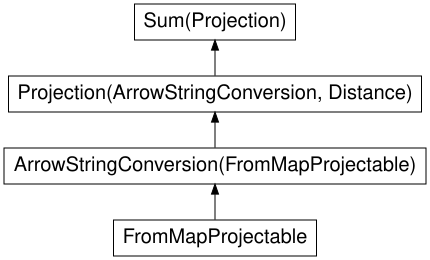

In [22]:
add.visualize() # In case this doesn't display the task graph eagerly, open "mydask.png" file created

We can executes this workflow with `compute()`:

In [23]:
%%time

add.compute()

CPU times: user 8.11 s, sys: 1.22 s, total: 9.33 s
Wall time: 6.88 s


np.float64(441526014.0)

### Partitions

Internally, Dask DataFrame is a collection of pandas DataFrames (these are actual pandas DataFrames internally as well!):

<img src="./images/dask-dataframe.svg" width="30%"/>

where each pandas DataFrame is called a "partition".

Your Dask computations will be run on all the individual pandas DataFrames in parallel, and then combined as necessary.

In [24]:
ddf.npartitions

3

Dask selects an adequate number of partitions based on your dataset and resource limits. If you use partitioned data formats, like Parquet (we'll learn more later!), Dask will preserve the partitions while reading data.

## Distributed computing

We can also leverage parallel computation on several different machines (workers) with their own processors and memory.
The different machines can interact to share data, and a central machine (scheduler) manages all the interactions.
Distributed computing refers to this system/model of computations.

These different machines can be located anywhere, on your local in-house network or in data centers around the world.

<img src="images/distributed-overview.png" width="50%"/>

## Dask Gateway

Dask Gateway is a library to manage Dask clusters on the cloud. The platform you're on (Nebari) has a Dask Gateway and ee'll create clusters using Google Cloud Provider machines in this tutorial.

<img src="images/gateway-architecture.svg" width="50%" />

First, import the library and create a new Gateway instance:

In [25]:
!pip install dask-gateway

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.2 MB/s eta 0:00:00


In [26]:
import dask_gateway

In [27]:
from dask.distributed import Client, LocalCluster

Tạo một cụm máy chủ cục bộ tận dụng chính máy ảo Colab hiện tại

In [28]:
cluster = LocalCluster()
client = Client(cluster)

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:34049
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:46189'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34707'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:42267 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:42267
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:39924
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:45829 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:45829
INFO:distributed.core:Starting established connection to tcp://127

Hiển thị thông tin

In [29]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34049,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45829,Total threads: 1
Dashboard: http://127.0.0.1:40535/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:46189,


### Manual vs adaptive scaling

You can specify the exact number of machines required in your cluster, and Dask will spin all of them up at the beginning. We call this approach "Manual scaling".

Dask Gateway also has a very useful "adaptive scaling" feature. This allows Dask to spin up new machines as your workflow/computation needs it, and then shut idle workers down safely after the computation is complete, until the next computation is triggered. Adaptive scaling can help manage costs when you have large compute requirements.

In the widget below, select adaptive scaling, set 3 (min) and 10 (max), and click "Adapt":

Finally, you can connect this cluster of machines to this IPython notebook using a client:

You slowly start getting new machines and you can see the Workers, Threads, and Memory increase in the "GatewayCluster" widget.

## Dask Dashboard

The Client widget displays a link to a dashboard:
* Click on it, and a new Keycloak sign-up page should open
* Login with the email and password you used to register
* The dashboard opens in the browser window

You will need to login only once, you should be able to access the Dashboard directly if you click on the link next time. :)

You can also access these plots within JupyterLab:
* Click on the Dask logo in the left sidebar
* Click on the magnifying glass icon, the dashboard should connect automatically and display available plots
* Open: "Cluster map", "task stream", and "progress" plots
* Re-arrange the plots in your JupyterLab interface to see them all together

Your instructor will talk about each plot as you work on the following computations!

## A quick computation

### 💻 Your turn: Compute the longest flight (distance) across the dataset

Make sure to look at the dashboard plots :)

In [30]:
# Your code here. When ready, click on the three dots below for the solution.
ddf["Distance"].max().compute()

5095.0

In [31]:
ddf["Distance"].max()
ddf["Distance"].max().compute()

5095.0

## Ensure cluster shutdown

Idling clusters can quickly add up to costs, so make sure to always shutdown your clusters after completing your work.

In [32]:
cluster.close()
client.close()

INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1789891093.9980876') (0, 1)
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:46189'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:34707'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:39932; closing.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:45829 name: 0 (stimulus_id='handle-worker-cleanup-1789891094.015723')
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:39924; closing.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:42267 name: 1 (stimulus_id='handle-worker-cleanup-1789891094.0242617')
INFO:distributed.scheduler:Lost all workers
INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:46189' closed.
INFO:distributed.nanny:Nanny at 'tc

---

## Next →

[Storage formats](./04-storage-formats.ipynb)!